# **💹Sales Analysis**

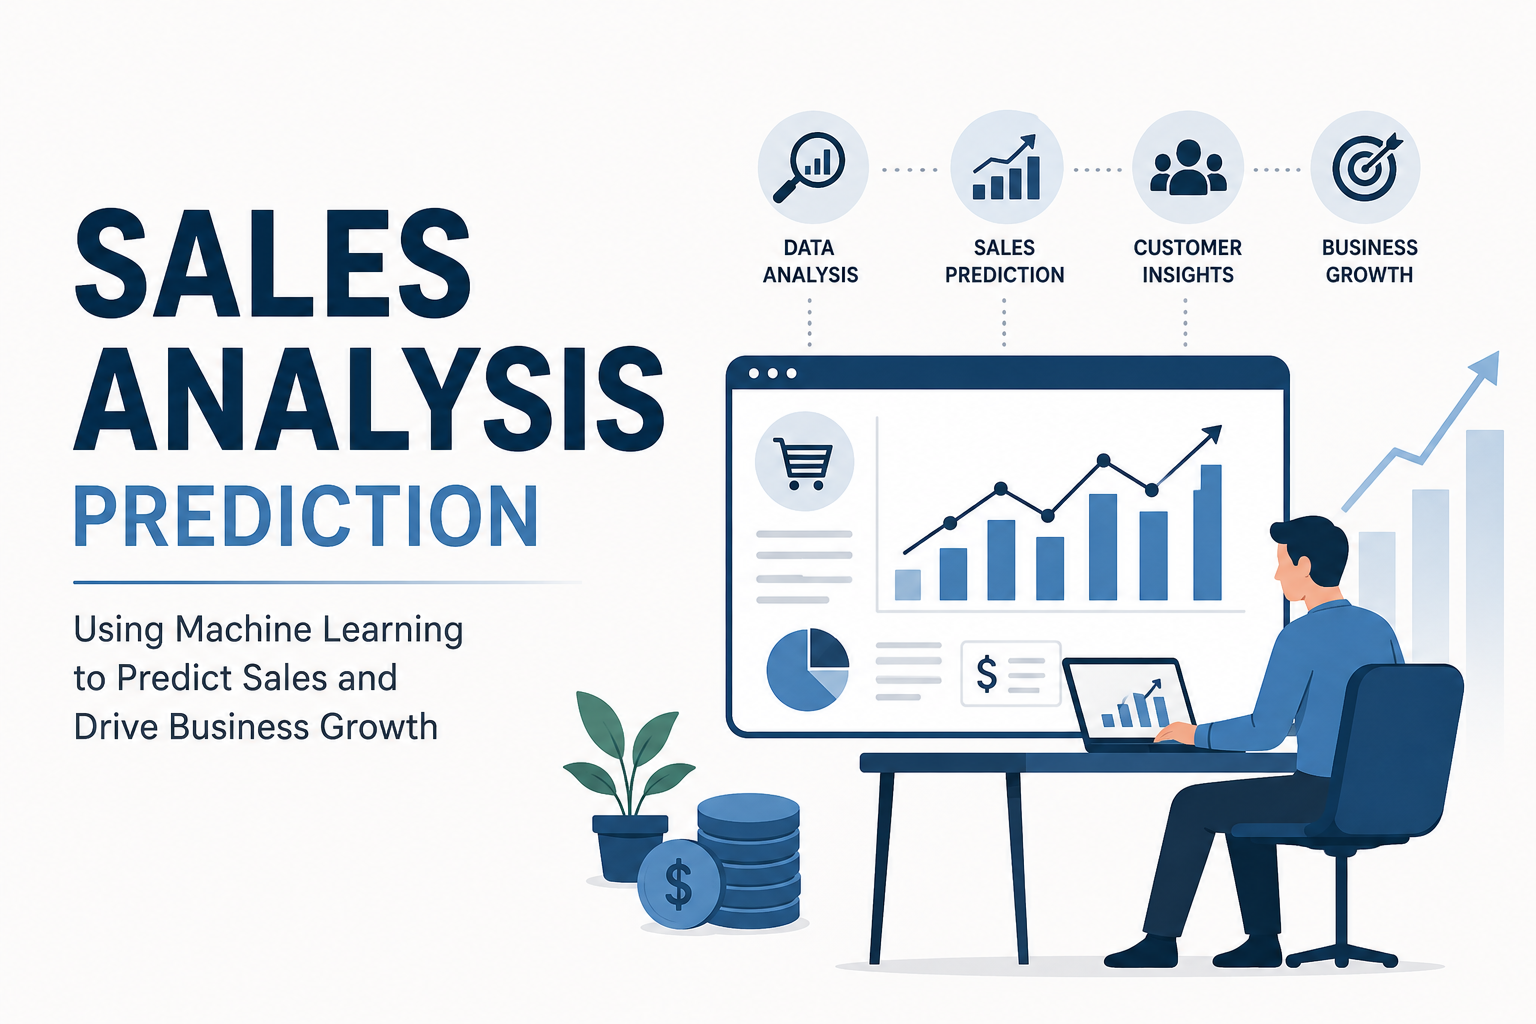

In [13]:
from IPython.display import Image,display
display(Image(filename='/content/sample_data/sales analysis.png',width=700))

# **TABLE OF CONTENTS**


1.IMPORTING LIBRARIES

2.LOADING DATA

3.DATA CLEANING

4.DATA PREPROCESSING

5.DATA VISUALIZATION

6.SEPARATING FEATURE AND TARGET

7.SCALING

8.DIMENSIONALITY REDUCTION (PCA)

9.KMEANS CLUSTERING

10.CONCLUSION

# **1)IMPORTING LIBRARIES**

In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

# **2)LOADING DATA**

In [2]:
df=pd.read_csv("/content/sample_data/train.csv")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


# **3)DATA CLEANING**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United States        Henderson   
1       CG-12520       Claire Gute   Consumer  United States        Henderson   
2       DV-13045   Darrin Van Huff  Corporate  United States      Los Angeles   
3       SO-20335    Sean O'Donnell   Consumer  United States  Fort Lauderdale   
4       SO-20335    Sean O'Donnell   Consumer  United States  Fort Lauderdale   
...          ...               ...        ...            ...              ...   
9795    SH-19975     Sally Hughsby  Corporate  United States          Chicago   
9796    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9797    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9798    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9799    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   

           State  Postal Code   Region       Product ID         Category  \
0       Kentucky      42420.0    South  FUR-BO-10001798        Furniture   
1       Kentucky      42420.0    South  FUR-CH-10000454        Furniture   
2     California      90036.0     West  OFF-LA-10000240  Office Supplies   
3        Florida      33311.0    South  FUR-TA-10000577        Furniture   
4        Florida      33311.0    South  OFF-ST-10000760  Office Supplies   
...          ...          ...      ...              ...              ...   
9795    Illinois      60610.0  Central  OFF-BI-10003429  Office Supplies   
9796        Ohio      43615.0     East  OFF-AR-10001374  Office Supplies   
9797        Ohio      43615.0     East  TEC-PH-10004977       Technology   
9798        Ohio      43615.0     East  TEC-PH-10000912       Technology   
9799        Ohio      43615.0     East  TEC-AC-10000487       Technology   

     Sub-Category                                       Product Name     Sales  
0       Bookcases                  Bush Somerset Collection Bookcase  261.9600  
1          Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs,...  731.9400  
2          Labels  Self-Adhesive Address Labels for Typewriters b...   14.6200  
3          Tables      Bretford CR4500 Series Slim Rectangular Table  957.5775  
4         Storage                     Eldon Fold 'N Roll Cart System   22.3680  
...           ...                                                ...       ...  
9795      Binders  Cardinal HOLDit! Binder Insert Strips,Extra St...    3.7980  
9796          Art           BIC Brite Liner Highlighters, Chisel Tip   10.3680  
9797       Phones                                        GE 30524EE4  235.1880  
9798       Phones           Anker 24W Portable Micro USB Car Charger   26.3760  
9799  Accessories                SanDisk Cruzer 4 GB USB Flash Drive   10.3840  

[9800 rows x 18 columns]>

# **4) DATA PREPROCESSING**

In [5]:
df.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
#To fill missing value['Medication']
df['Postal Code']=df['Postal Code'].fillna(df['Postal Code'].mode()[0])
df.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [8]:
#To change the object to int or float(numerical values)
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Order ID']=encoder.fit_transform(df['Order ID'])
df['Order Date']=encoder.fit_transform(df['Order Date'])
df['Ship Date']=encoder.fit_transform(df['Ship Date'])
df['Ship Mode']=encoder.fit_transform(df['Ship Mode'])
df['Customer ID']=encoder.fit_transform(df['Customer ID'])
df['Customer Name']=encoder.fit_transform(df['Customer Name'])
df['Segment']=encoder.fit_transform(df['Segment'])
df['Country']=encoder.fit_transform(df['Country'])
df['City']=encoder.fit_transform(df['City'])
df['State']=encoder.fit_transform(df['State'])
df['Region']=encoder.fit_transform(df['Region'])
df['Product ID']=encoder.fit_transform(df['Product ID'])
df['Category']=encoder.fit_transform(df['Category'])
df['Sub-Category']=encoder.fit_transform(df['Sub-Category'])
df['Product Name']=encoder.fit_transform(df['Product Name'])
df['Sales']=encoder.fit_transform(df['Sales'])
df.dtypes


,0
Row ID,int64
Order ID,int64
Order Date,int64
Ship Date,int64
Ship Mode,int64
Customer ID,int64
Customer Name,int64
Segment,int64
Country,int64
City,int64


# **5) Data Visualization**

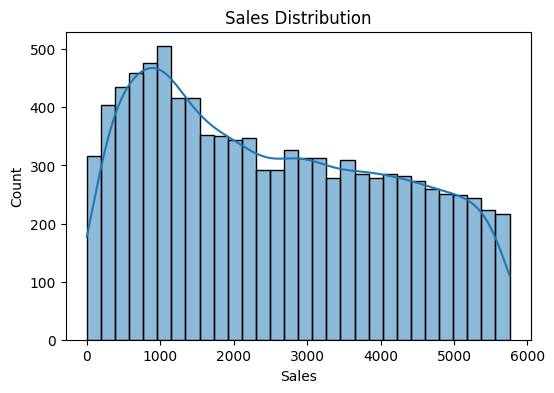

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

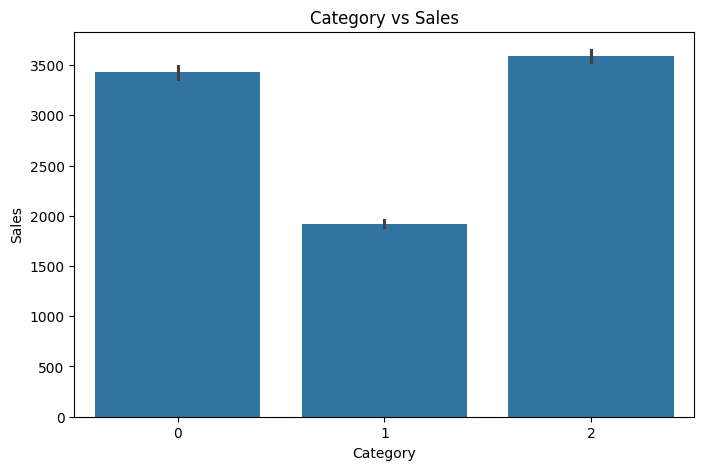

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Category vs Sales")
plt.show()

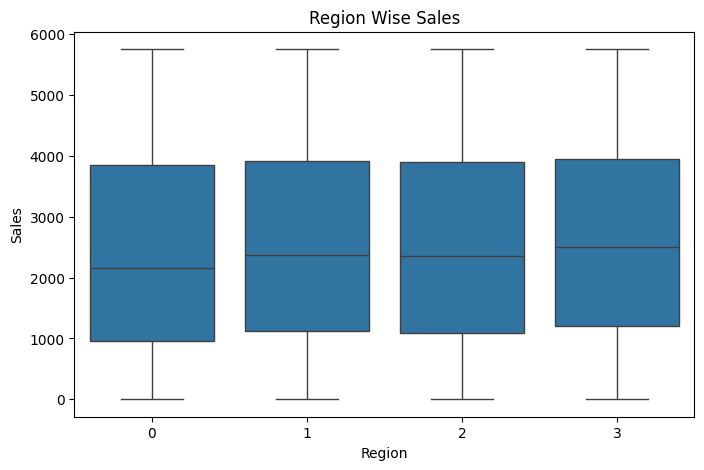

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Region', y='Sales', data=df)
plt.title("Region Wise Sales")
plt.show()

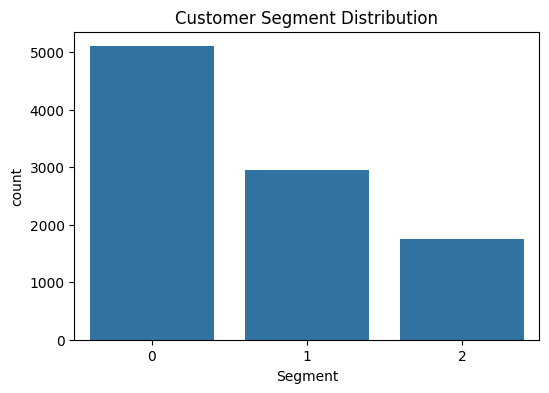

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='Segment', data=df)
plt.title("Customer Segment Distribution")
plt.show()

# **6) SEPARATING FEATURE AND TARGET**

In [34]:
x=df.iloc[:,:-1]
x

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
0,1,2456,314,476,2,143,166,0,0,194,15,42420.0,2,12,0,4,386
1,2,2456,314,476,2,143,166,0,0,194,15,42420.0,2,55,0,5,838
2,3,2254,456,673,2,237,201,1,0,265,3,90036.0,3,946,1,10,1432
3,4,4295,432,774,3,705,687,0,0,153,8,33311.0,2,319,0,16,366
4,5,4295,432,774,3,705,687,0,0,153,8,33311.0,2,1316,1,14,573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,2064,821,1191,3,691,663,1,0,80,11,60610.0,0,773,1,3,408
9796,9797,1144,441,697,3,179,164,1,0,483,33,43615.0,1,515,1,2,277
9797,9798,1144,441,697,3,179,164,1,0,483,33,43615.0,1,1860,2,13,724
9798,9799,1144,441,697,3,179,164,1,0,483,33,43615.0,1,1706,2,13,148


In [38]:
y=df.iloc[:,-1]
y

,Sales
0,4156
1,5158
2,956
3,5329
4,1345
...,...
9795,195
9796,675
9797,4020
9798,1506


# **7) SCALING**

In [40]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [41]:
scaler.fit(x)

MinMaxScaler()

In [42]:
x_scaled=scaler.fit_transform(x)
x_scaled

array([[0.00000000e+00, 4.99085552e-01, 2.55492270e-01, ...,
        0.00000000e+00, 2.50000000e-01, 2.08874459e-01],
       [1.02051230e-04, 4.99085552e-01, 2.55492270e-01, ...,
        0.00000000e+00, 3.12500000e-01, 4.53463203e-01],
       [2.04102459e-04, 4.58036984e-01, 3.71033360e-01, ...,
        5.00000000e-01, 6.25000000e-01, 7.74891775e-01],
       ...,
       [9.99795898e-01, 2.32473075e-01, 3.58828316e-01, ...,
        1.00000000e+00, 8.12500000e-01, 3.91774892e-01],
       [9.99897949e-01, 2.32473075e-01, 3.58828316e-01, ...,
        1.00000000e+00, 8.12500000e-01, 8.00865801e-02],
       [1.00000000e+00, 2.32473075e-01, 3.58828316e-01, ...,
        1.00000000e+00, 0.00000000e+00, 7.57034632e-01]])

# **8)  DIMENSIONALITY REDUCTION (PCA)**

In [43]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df.head()

,PC1,PC2
0,0.084642,-0.819476
1,0.088540,-0.739805
2,0.706556,0.097689
3,0.072684,-0.454068
4,0.072848,0.228203


In [44]:
print(pca.explained_variance_ratio_)

[0.14563408 0.11240373]


**CLUSTERING**

**Elbow Method**

In [56]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

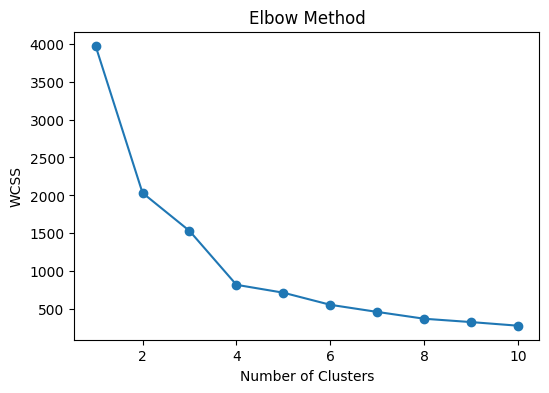

In [57]:
plt.figure(figsize=(6,4))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# **9)  K-MEANS CLUSTERING**

**Train Model**

In [58]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(pca_data)

pca_df['Cluster'] = clusters

**Visualize Clusters**

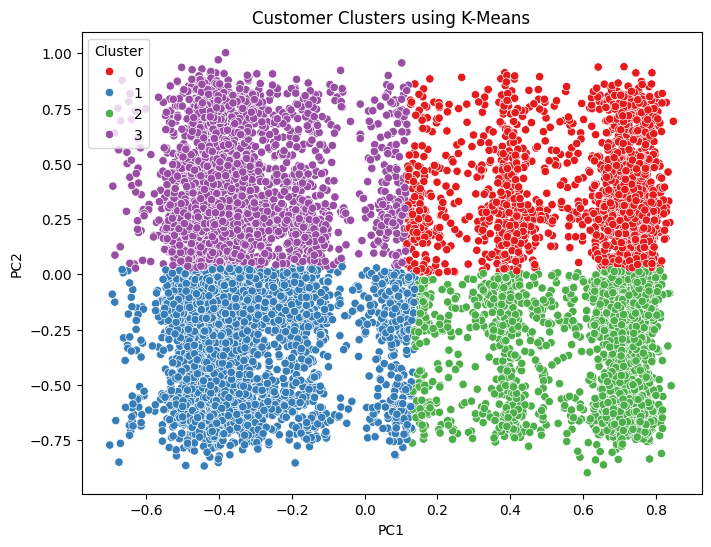

In [59]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("Customer Clusters using K-Means")
plt.show()

**Add Cluster to Original Dataset**

In [60]:
df['Cluster'] = clusters

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Cluster
0,1,2456,314,476,2,143,166,0,0,194,15,42420.0,2,12,0,4,386,4156,1
1,2,2456,314,476,2,143,166,0,0,194,15,42420.0,2,55,0,5,838,5158,1
2,3,2254,456,673,2,237,201,1,0,265,3,90036.0,3,946,1,10,1432,956,0
3,4,4295,432,774,3,705,687,0,0,153,8,33311.0,2,319,0,16,366,5329,1
4,5,4295,432,774,3,705,687,0,0,153,8,33311.0,2,1316,1,14,573,1345,3


**Cluster Summary**

In [61]:
df.groupby('Cluster')['Sales'].agg(
    ['count','mean','max','min']
)

,count,mean,max,min
Cluster,,,,
0,1713,2796.116754,5754,7
1,3420,2324.685965,5751,0
2,1847,2451.369789,5738,9
3,2820,2731.381206,5756,15


# **10) CONCLUSION**



* The sales dataset was successfully cleaned and preprocessed.

* Missing values in Postal Code were handled.

* Feature engineering was performed by extracting Shipping Days, Order Month, and Order Year.

* PCA reduced the dataset into two principal components while     preserving important information.

* K-Means clustering grouped similar sales records into 4 clusters.

* The clusters helped identify different sales patterns and customer segments.

* High-sales and low-sales groups were clearly separated.

* Businesses can use these insights for customer targeting, inventory planning, and sales strategy optimization.